# Phase 6 — Verified Contract Relationship Graph

**Roadmap reference:** `06_Knowledge_Graph.ipynb`

**Adversarial check done before writing any graph code:** every parsed
document was grepped for genuine cross-references (dates, contract
numbers, "pursuant to", "renews"). Finding: this corpus has **no
document-to-document relationship where both ends are provably the same
real document** — every MLA/TXN/FIN/COM document reuses the same two
boilerplate party names ("PrimeVolta Hardware Solutions" / "FinSecure
Services"), so shared party names prove nothing, and the four documents
that do explicitly reference another agreement (TXN-001..004) reference
one that is **not present anywhere in the 34-document manifest** (no
matching date/number on any other doc).

**What this notebook builds instead — still real, still evidence-backed:**
1. `document --BELONGS_TO--> category` (real Phase 0 manifest metadata)
2. `document --CONTAINS--> party` (self-extracted from each document's OWN
   party clause, several real phrasing styles measured and handled)
3. `document --RENEWS/REFERENCES--> external_reference` for the 4 genuine
   cross-references found, pointing to a clearly-labeled node that is
   explicitly **not** resolved to any doc_id in this corpus

**Completion gate:** every edge in the graph carries `evidence_ids` and
`verification_status`; nothing is derived from filename similarity or from
two documents merely sharing the same placeholder party names.

## 1. Load configuration and the manifest

In [1]:
import sys
sys.path.append("..")

from src.contractiq.ingestion import load_manifest
from src.contractiq.graph import ContractKnowledgeGraph, EXTERNAL_REFERENCES

manifest = load_manifest()
print(f"Loaded manifest: {len(manifest)} documents")
print(f"Manually verified external cross-references found in this corpus: {list(EXTERNAL_REFERENCES)}")


Loaded manifest: 36 documents
Manually verified external cross-references found in this corpus: ['TXN-001', 'TXN-002', 'TXN-003', 'TXN-004']


## 2. Build the graph from the real manifest

`build_from_manifest()` adds, for every document:
- a `BELONGS_TO` edge to its category (always added — real Phase 0 metadata)
- a `CONTAINS` edge to each party named in its own text (only if a known
  party-naming pattern actually matches that document's own clauses)
- a `RENEWS`/`REFERENCES` edge to an external node, only for the 4
  documents manually verified to contain one

The returned summary reports gaps honestly — which documents had no
extractable party clause — instead of hiding them.

In [2]:
kg = ContractKnowledgeGraph()
build_summary = kg.build_from_manifest(manifest)

print(f"documents: {build_summary['documents']}")
print(f"total_nodes: {build_summary['total_nodes']}")
print(f"total_edges: {build_summary['total_edges']}")
print()
print(f"party clause FOUND for {len(build_summary['party_edges_added_for'])} docs:")
print(f"  {build_summary['party_edges_added_for']}")
print()
print(f"party clause NOT found for {len(build_summary['party_clause_not_found_for'])} docs "
      f"(genuinely no party-naming text matched, not hidden):")
print(f"  {build_summary['party_clause_not_found_for']}")
print()
print(f"external reference edges added for: {build_summary['external_reference_edges_added_for']}")


documents: 36
total_nodes: 50
total_edges: 68

party clause FOUND for 14 docs:
  ['COM-001', 'COM-002', 'GOV-003', 'GOV-004', 'NEG-003', 'NEG-004', 'NEG-005', 'NEG-006', 'MLA-001', 'MLA-002', 'MLA-003', 'MLA-004', 'MLA-005', 'MLA-006']

party clause NOT found for 22 docs (genuinely no party-naming text matched, not hidden):
  ['CMP-001', 'CMP-002', 'CMP-003', 'CMP-004', 'CMP-005', 'CMP-006', 'GOV-001', 'GOV-002', 'FIN-001', 'FIN-002', 'FIN-003', 'FIN-004', 'NEG-001', 'NEG-002', 'OPS-001', 'OPS-002', 'OPS-003', 'OPS-004', 'TXN-001', 'TXN-002', 'TXN-003', 'TXN-004']

external reference edges added for: ['TXN-001', 'TXN-002', 'TXN-003', 'TXN-004']


## 3. Query the graph

Each query walks real edges — `get_documents_by_category` and
`get_documents_by_party` return documents via their `BELONGS_TO`/`CONTAINS`
edges; `get_external_references` returns a document's own cross-reference
evidence; `find_potentially_same_external_reference` flags candidate merges
for human review (never auto-merges on party-name-only evidence);
`find_missing_legal_protections` reuses Phase 4's already-verified legal
findings rather than inventing a new "risk" heuristic.

In [3]:
print("Documents in category 'master_agreements':")
print(" ", kg.get_documents_by_category("master_agreements"))

print("\nDocuments naming party 'FinSecure Services':")
print(" ", kg.get_documents_by_party("FinSecure Services"))

print("\nExternal references cited by TXN-001:")
for ref in kg.get_external_references("TXN-001"):
    print(f"   -> {ref['relation']} {ref['target']}")
    print(f"      label: {ref['label']}")
    print(f"      evidence_ids: {ref['evidence_ids']}")

print("\nExternal references that might be the SAME unnamed agreement (flagged, not merged):")
for group in kg.find_potentially_same_external_reference():
    print(f"   candidate group: {group}")

print("\nMissing legal protections per master-agreement document (from Phase 4's verified findings):")
for doc_id, missing_topics in kg.find_missing_legal_protections().items():
    print(f"   {doc_id}: {missing_topics}")


Documents in category 'master_agreements':
  ['MLA-001', 'MLA-002', 'MLA-003', 'MLA-004', 'MLA-005', 'MLA-006']

Documents naming party 'FinSecure Services':
  ['COM-001', 'COM-002', 'GOV-003', 'GOV-004', 'NEG-003', 'NEG-004', 'NEG-005', 'NEG-006', 'MLA-001', 'MLA-002', 'MLA-003', 'MLA-004', 'MLA-005', 'MLA-006']

External references cited by TXN-001:
   -> RENEWS EXTERNAL:AMSA-2025-01-01
      label: Original Annual Maintenance & Support Agreement (AMSA), executed 2025-01-01 — not present in this corpus
      evidence_ids: ['TXN-001-p5']

External references that might be the SAME unnamed agreement (flagged, not merged):
   candidate group: ['EXTERNAL:MSA-referenced-by-TXN-003', 'EXTERNAL:MSA-referenced-by-TXN-004']

Missing legal protections per master-agreement document (from Phase 4's verified findings):
   MLA-001: ['assignment_change_of_control']
   MLA-002: ['assignment_change_of_control']
   MLA-003: ['indemnification', 'liability_cap', 'termination_for_convenience']
   MLA-004

## 4. Visualize — static (matplotlib) and interactive (PyVis)

Node colors: green = document, teal = category, blue = party, red = external
reference (clearly distinct from a real in-corpus document node).

Static PNG saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\reports\phase6_contract_knowledge_graph.png
Interactive HTML saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\reports\phase6_contract_knowledge_graph.html
Edge list (relation + evidence_ids + verification_status) saved to: E:\Sheriff_faang\full_end_to_end_project_implementation\IK_PWC_Agentic_AI_Project\PWC_CAPSTONE_PROJECT\IK_PWC_COURSE_CAPSTONE_PROJECTS\PWC_CONTRACTIQ_PROJECT\artifacts\reports\phase6_graph_edges.json


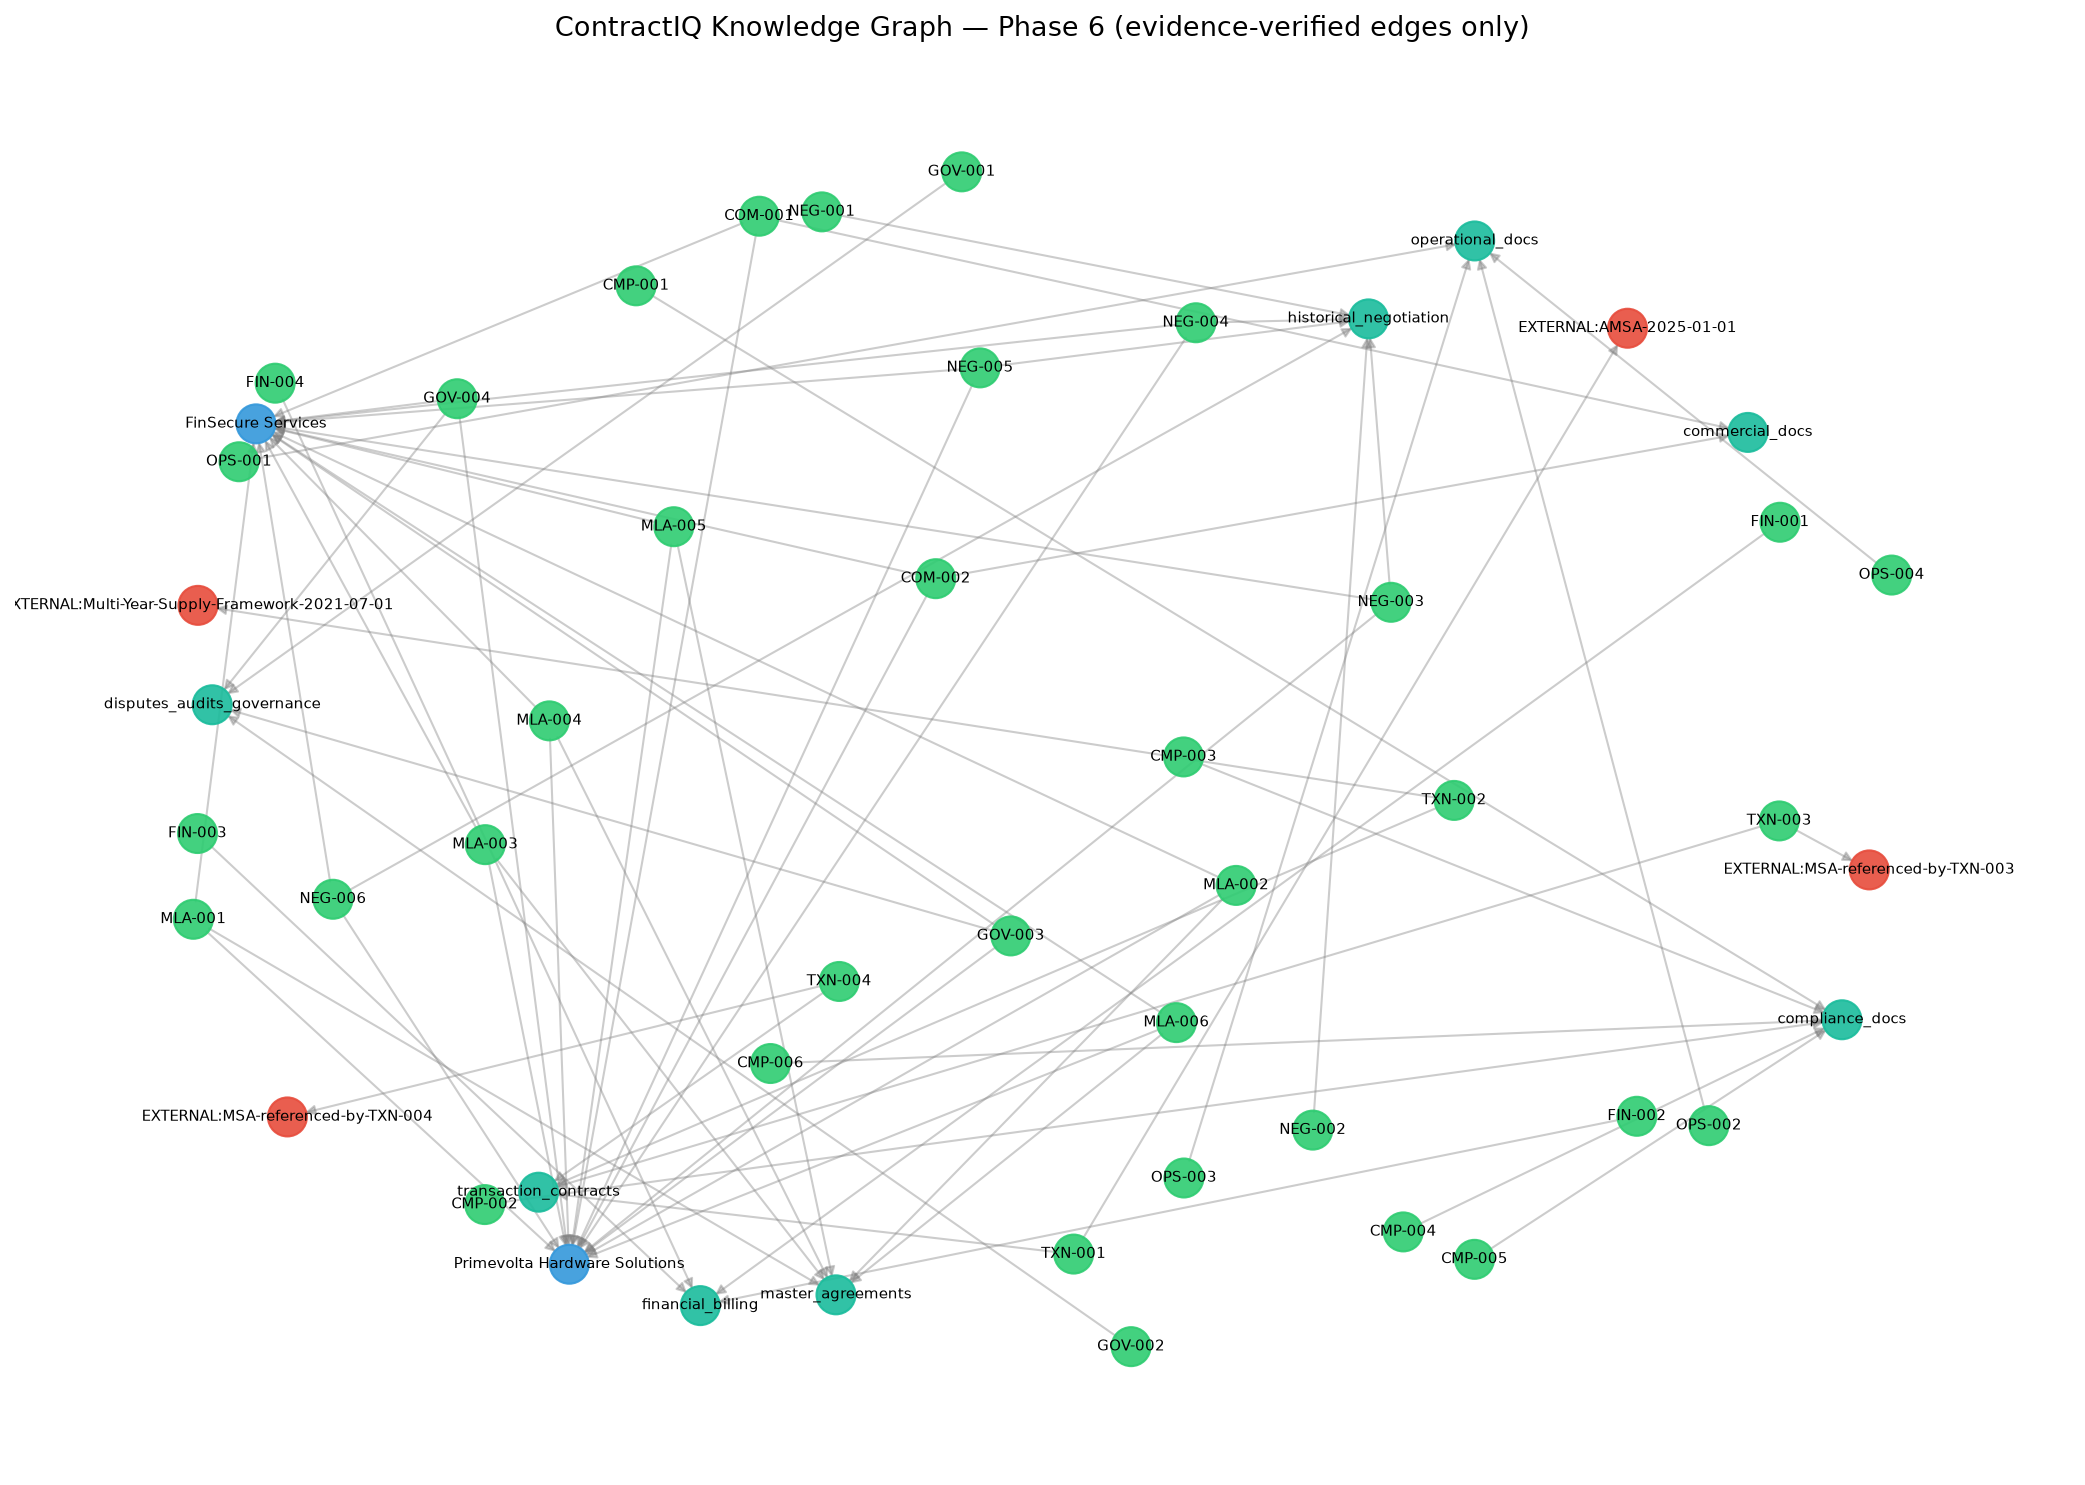

In [4]:
png_path = kg.visualize_matplotlib()
html_path = kg.visualize_interactive()
edges_path = kg.save_edges()

print(f"Static PNG saved to: {png_path}")
print(f"Interactive HTML saved to: {html_path}")
print(f"Edge list (relation + evidence_ids + verification_status) saved to: {edges_path}")

from IPython.display import Image, display
display(Image(filename=str(png_path)))


In [5]:
display(html_path)

WindowsPath('E:/Sheriff_faang/full_end_to_end_project_implementation/IK_PWC_Agentic_AI_Project/PWC_CAPSTONE_PROJECT/IK_PWC_COURSE_CAPSTONE_PROJECTS/PWC_CONTRACTIQ_PROJECT/artifacts/reports/phase6_contract_knowledge_graph.html')

## Honest status of Phase 6 at this point

- **Built:** `ContractKnowledgeGraph` over real documents — `BELONGS_TO`
  (document→category, from real manifest metadata), `CONTAINS`
  (document→party, self-extracted per document), and
  `RENEWS`/`REFERENCES` (document→external_reference) for the 4
  genuinely-verified cross-references in this corpus. Every edge carries
  `evidence_ids` + `verification_status`.
- **Measured, not assumed:** party-clause extraction started at 8/36
  documents (one regex pattern), then was extended to 14/36 after reading
  the actual text of "not found" documents and adding two more real
  phrasing styles seen in this corpus (`"Between: X (Role)\nAnd: Y (Role)"`
  and independent `"Client:"`/`"Vendor:"` labels). A real bug was caught in
  the process — a regex consuming the newline it needed as the next
  match's start-anchor, silently preventing the `Vendor:` label from ever
  matching — found by testing against real text, not assumed working.
- **Known, reported limitation:** 22/36 documents have no extractable
  party clause — for compliance/policy documents (`CMP-*`) this is because
  they genuinely never restate contract parties; for others (`FIN-*`,
  `OPS-*`, `TXN-*`) it's because they use yet other phrasings not covered
  here. Extending further has diminishing returns; this is reported
  honestly rather than guessed at.
- **Deliberately NOT built:** any edge asserting a specific document is
  "the MSA" that a given SOW/Renewal refers to — this corpus does not
  contain enough evidence to prove that link for any specific pair, so no
  such edge exists, matching the roadmap's explicit warning against
  deriving relationships from filename or party-name similarity alone.
- **Not built yet (Phase 7+):** the frozen cross-specialist evaluation set,
  and the Gradio UI.